In [6]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import random

In [7]:
env = gym.make("CartPole-v1")
print(env.action_space)
print(env.observation_space)
print(env.action_space.sample())

Discrete(2)
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
0


In [8]:
env.reset()

for i in range(100):
   env.render()
   env.step(env.action_space.sample())
env.close()

c:\Users\jsand\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\classic_control\cartpole.py:251: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CartPole-v1", render_mode="rgb_array")
  gym.logger.warn(
c:\Users\jsand\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\envs\classic_control\cartpole.py:213: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


In [11]:
env.reset()

done = False
while not done:
   env.render()
   obs, rew, terminated, truncated, info = env.step(env.action_space.sample())
   done = terminated or truncated
   print(f"{obs} -> {rew}")
env.close()

[ 0.02031397  0.19966578  0.00296436 -0.29056486] -> 1.0
[ 0.02430729  0.0045017  -0.00284694  0.00305152] -> 1.0
[ 0.02439732  0.19966435 -0.00278591 -0.2905283 ] -> 1.0
[ 0.02839061  0.39482594 -0.00859647 -0.58408856] -> 1.0
[ 0.03628713  0.59006727 -0.02027824 -0.879467  ] -> 1.0
[ 0.04808848  0.78545874 -0.03786758 -1.1784555 ] -> 1.0
[ 0.06379765  0.98105145 -0.06143669 -1.4827646 ] -> 1.0
[ 0.08341868  1.1768665  -0.09109198 -1.7939842 ] -> 1.0
[ 0.10695601  0.98287565 -0.12697166 -1.5309482 ] -> 1.0
[ 0.12661353  0.7894925  -0.15759063 -1.2804381 ] -> 1.0
[ 0.14240338  0.9862317  -0.18319939 -1.6180301 ] -> 1.0
[ 0.162128    0.79368097 -0.21555999 -1.3875971 ] -> 1.0


In [12]:
print(env.observation_space.low)
print(env.observation_space.high)

[-4.8               -inf -0.41887903        -inf]
[4.8               inf 0.41887903        inf]


In [17]:
def discretize(x):
    return tuple((x/np.array([0.25, 0.25, 0.01, 0.1])).astype(int))

In [18]:
def create_bins(i,num):
    return np.arange(num+1)*(i[1]-i[0])/num+i[0]

print("Sample bins for interval (-5,5) with 10 bins\n",create_bins((-5,5),10))

ints = [(-5,5),(-2,2),(-0.5,0.5),(-2,2)] # intervals of values for each parameter
nbins = [20,20,10,10] # number of bins for each parameter
bins = [create_bins(ints[i],nbins[i]) for i in range(4)]

def discretize_bins(x):
    return tuple(np.digitize(x[i],bins[i]) for i in range(4))

Sample bins for interval (-5,5) with 10 bins
 [-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.]


In [19]:
env.reset()

done = False
while not done:
   #env.render()
   obs, rew, terminated, truncated, info = env.step(env.action_space.sample())
   done = terminated or truncated
   #print(discretize_bins(obs))
   print(discretize(obs))
env.close()

(0, 0, -2, 2)
(0, 0, -2, 0)
(0, 0, -2, 2)
(0, -1, -1, 5)
(0, 0, 0, 2)
(0, 0, 0, 0)
(0, 0, 0, -3)
(0, 0, -1, 0)
(0, 0, -1, 2)
(0, -1, 0, 5)
(0, 0, 0, 2)
(0, 0, 0, 0)
(0, 0, 0, -3)
(0, 1, 0, -6)
(0, 0, -1, -3)
(0, 0, -2, 0)
(0, 0, -2, 2)
(0, -1, -2, 4)
(0, 0, -1, 1)
(0, -1, 0, 4)
(0, -2, 0, 7)
(0, -1, 1, 4)
(0, 0, 2, 1)
(0, -1, 3, 4)
(0, 0, 4, 2)
(0, -1, 4, 5)
(0, -2, 5, 8)
(0, -2, 7, 11)
(0, -2, 9, 8)
(0, -2, 11, 11)
(0, -2, 13, 9)
(0, -2, 15, 12)
(0, -2, 17, 10)
(0, -1, 19, 7)
(0, -2, 21, 11)


In [20]:
Q = {}
actions = (0,1)

def qvalues(state):
    return [Q.get((state,a),0) for a in actions]

In [21]:
# hyperparameters
alpha = 0.3
gamma = 0.9
epsilon = 0.90

In [24]:
def probs(v,eps=1e-4):
    v = v-v.min()+eps
    v = v/v.sum()
    return v

Qmax = 0
cum_rewards = []
rewards = []
for epoch in range(100000):
    obs, info = env.reset()
    done = False
    cum_reward=0
    # == do the simulation ==
    while not done:
        s = discretize(obs)
        if random.random()<epsilon:
            # exploitation - chose the action according to Q-Table probabilities
            v = probs(np.array(qvalues(s)))
            a = random.choices(actions,weights=v)[0]
        else:
            # exploration - randomly chose the action
            a = np.random.randint(env.action_space.n)

        obs, rew, terminated, truncated, info = env.step(a)
        done = terminated or truncated
        cum_reward+=rew
        ns = discretize(obs)
        Q[(s,a)] = (1 - alpha) * Q.get((s,a),0) + alpha * (rew + gamma * max(qvalues(ns)))
    cum_rewards.append(cum_reward)
    rewards.append(cum_reward)
    # == Periodically print results and calculate average reward ==
    if epoch%5000==0:
        print(f"{epoch}: {np.average(cum_rewards)}, alpha={alpha}, epsilon={epsilon}")
        if np.average(cum_rewards) > Qmax:
            Qmax = np.average(cum_rewards)
            Qbest = Q
        cum_rewards=[]

0: 11.0, alpha=0.3, epsilon=0.9
5000: 89.3592, alpha=0.3, epsilon=0.9
10000: 113.0406, alpha=0.3, epsilon=0.9
15000: 131.9586, alpha=0.3, epsilon=0.9
20000: 142.6458, alpha=0.3, epsilon=0.9
25000: 150.3406, alpha=0.3, epsilon=0.9
30000: 154.4028, alpha=0.3, epsilon=0.9
35000: 157.2512, alpha=0.3, epsilon=0.9
40000: 155.5992, alpha=0.3, epsilon=0.9
45000: 146.8258, alpha=0.3, epsilon=0.9
50000: 147.7494, alpha=0.3, epsilon=0.9
55000: 142.381, alpha=0.3, epsilon=0.9
60000: 151.539, alpha=0.3, epsilon=0.9
65000: 149.722, alpha=0.3, epsilon=0.9
70000: 147.2672, alpha=0.3, epsilon=0.9
75000: 148.3016, alpha=0.3, epsilon=0.9
80000: 145.4812, alpha=0.3, epsilon=0.9
85000: 141.628, alpha=0.3, epsilon=0.9
90000: 139.6418, alpha=0.3, epsilon=0.9
95000: 139.8172, alpha=0.3, epsilon=0.9


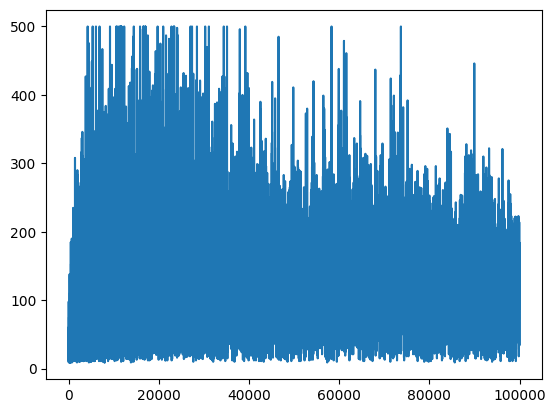

In [25]:
plt.plot(rewards)

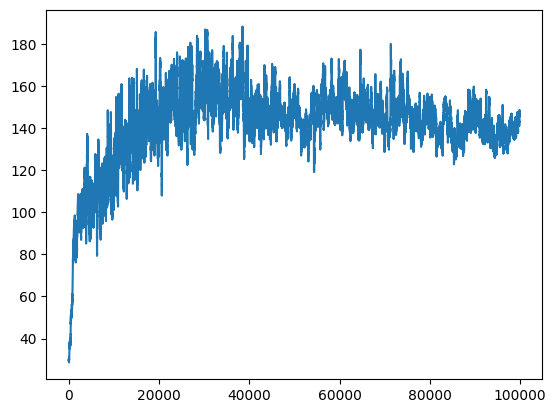

In [26]:
def running_average(x,window):
    return np.convolve(x,np.ones(window)/window,mode='valid')

plt.plot(running_average(rewards,100))

In [34]:
env = gym.make("CartPole-v1", render_mode="human")

In [35]:
obs, info = env.reset()
done = False

while not done:
   s = discretize(obs)

   env.render()

   v = probs(np.array(qvalues(s)))
   a = random.choices(actions, weights=v)[0]

   obs, _, terminated, truncated, _ = env.step(a)
   done = terminated or truncated

env.close()